### Algorisme d'agrupament espectral aplicat al sistema de Duffing autònom

In [2]:
import sys
sys.path.append("..")
from src import *
import numpy as np
np.set_printoptions(precision=3, suppress=True)
%load_ext autoreload
%autoreload 2

In [3]:
params = ParametresGenerals(
    dimensio = 2,
    t_span = (0, 4 * np.pi),
    t_steps = 300,
    x_min = -1.6,
    x_max = 1.6,
    y_min = -1.0,
    y_max = 1.0,
    espai_entre_punts = 0.04,
    max_clusters = 50,
    num_radis = 50
)

In [4]:
condicions_inicials = generar_condicions_inicials(params)
trajectories = generar_trajectories(edo_duffing_autonom, condicions_inicials, params)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)

(Num trajectories, t_steps, dimensio) = (4131, 300, 2)


In [5]:
matriu_pesos = calcula_matriu_pesos(trajectories)

In [6]:
pes_max = np.max(matriu_pesos)
print(f"Pes màxim a la matriu de pesos: {pes_max:.3f}")
constant_diagonal = pes_max * 1e7

Pes màxim a la matriu de pesos: 107.033


##### Opció A: esparsificar al 90%

S'ha obtingut una esparsificació del 90% usant 1.313 com a radi d'esparsificació.
matriu_similaritat_W =
 [[1.070e+09 1.851e+01 8.962e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [1.851e+01 1.070e+09 1.729e+01 ... 0.000e+00 0.000e+00 0.000e+00]
 [8.962e+00 1.729e+01 1.070e+09 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 1.070e+09 1.729e+01 8.962e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 1.729e+01 1.070e+09 1.851e+01]
 [0.000e+00 0.000e+00 0.000e+00 ... 8.962e+00 1.851e+01 1.070e+09]]
veps.shape = (4131, 50)
50 vaps = [-7.3e-19 8.8e-09 1.2e-08 1.2e-08 1.5e-08 2.3e-08 2.6e-08 4.6e-08 4.9e-08
 5.2e-08 5.3e-08 6.2e-08 6.4e-08 6.5e-08 7.3e-08 7.3e-08 8.2e-08 8.2e-08
 8.7e-08 9.3e-08 9.4e-08 9.4e-08 9.5e-08 9.5e-08 9.9e-08 9.9e-08 1.0e-07
 1.0e-07 1.0e-07 1.1e-07 1.1e-07 1.1e-07 1.1e-07 1.2e-07 1.2e-07 1.2e-07
 1.2e-07 1.2e-07 1.2e-07 1.2e-07 1.3e-07 1.3e-07 1.3e-07 1.3e-07 1.4e-07
 1.4e-07 1.4e-07 1.4e-07 1.4e-07 1.4e-07]


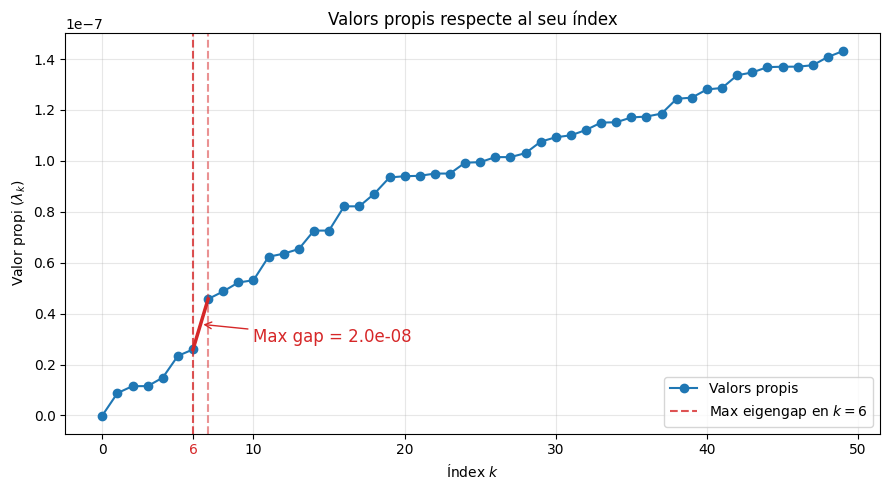

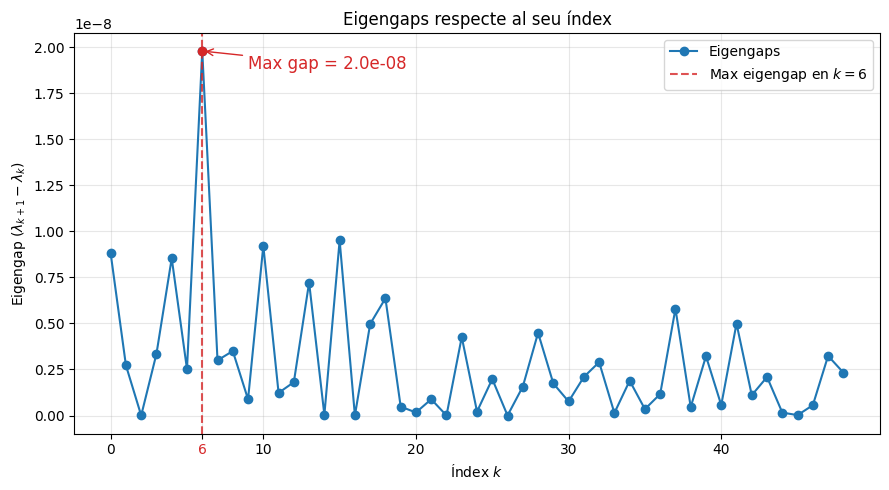

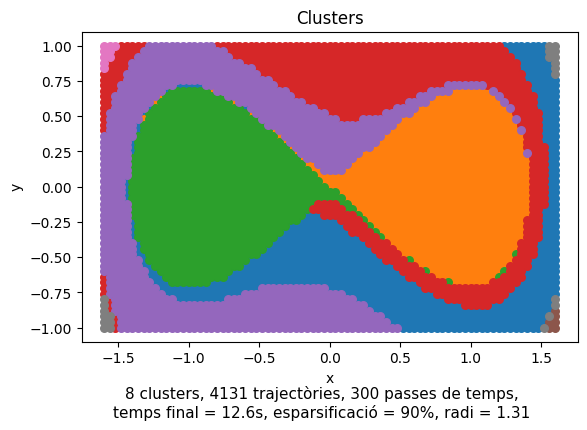

In [7]:
matriu_similaritat_W, radi_esparsificacio, percentatge_esparsificacio = \
      sparcify(matriu_pesos, percent=90)
print(f"S'ha obtingut una esparsificació del {percentatge_esparsificacio*100:.0f}% "
      f"usant {radi_esparsificacio:.3f} com a radi d'esparsificació.")
np.fill_diagonal(matriu_similaritat_W, constant_diagonal)
print("matriu_similaritat_W =\n", matriu_similaritat_W)
vaps, veps = calcula_vaps(matriu_similaritat_W, params.max_clusters)
print("veps.shape =", veps.shape)
print(len(vaps),"vaps =",np.array2string(vaps,formatter={'float_kind':lambda x:f'{x:.1e}'}))
grafica_eigenvalues_vs_index(vaps, subfolder="autonom")
grafica_eigengaps_vs_index(vaps, subfolder="autonom")
num_clusters, diff_max = calcula_num_clusters_i_max_eigengap(vaps)
labels = troba_clusters(num_clusters, veps)
grafica_clusters(condicions_inicials, labels, num_clusters, radi_esparsificacio, 
                 percentatge_esparsificacio, params, subfolder="autonom")

##### Opció B: mètode adaptatiu. Es trien els radis d'esparsificació que maximitzen l'eigengap màxim

In [8]:
result = calcula_indicadors_vs_radis(matriu_pesos, constant_diagonal, params)

indexs_max_rel = [3, 37, 41]
radis[indexs_max_rel] = [0.395 1.433 1.555]
Màxim_relatiu_num 1
Radi: 0.395, Esparsificació: 0.65%, Clústers: 2, Max eigengap: 2.08107e-06


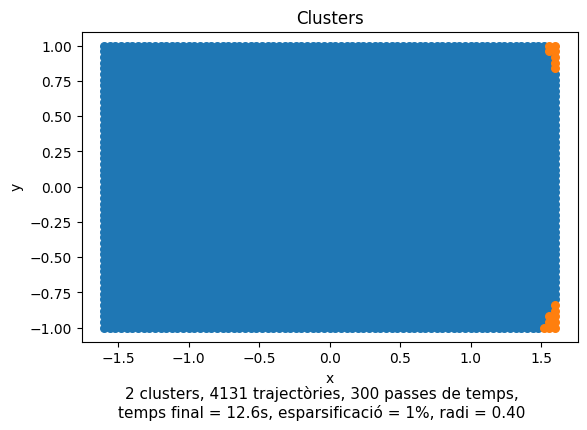

Màxim_relatiu_num 2
Radi: 1.433, Esparsificació: 91.66%, Clústers: 8, Max eigengap: 1.78715e-08


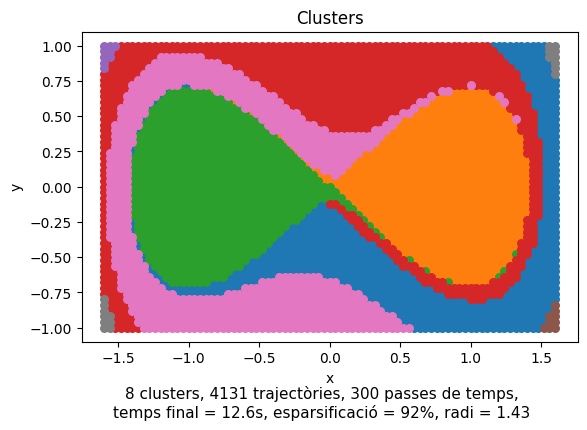

Màxim_relatiu_num 3
Radi: 1.555, Esparsificació: 93.13%, Clústers: 8, Max eigengap: 1.46908e-08


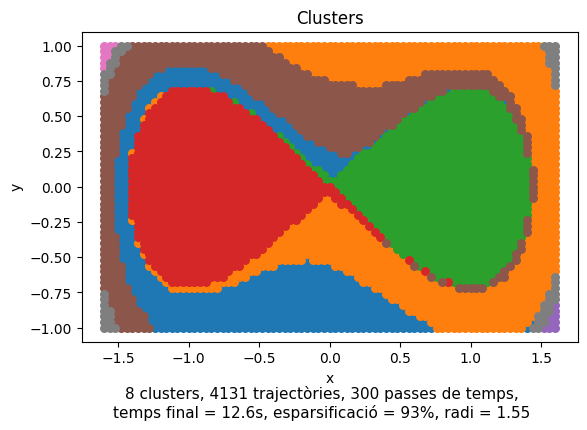

In [9]:
indexs_max_rel = troba_indexs_max_rel(result.normalized_eigengaps)
print("indexs_max_rel =", indexs_max_rel)
print("radis[indexs_max_rel] =", result.radis[indexs_max_rel])
grafica_clusters_maxs_rel(indexs_max_rel, result, condicions_inicials, 
                          params, subfolder="autonom_maxs_rels")

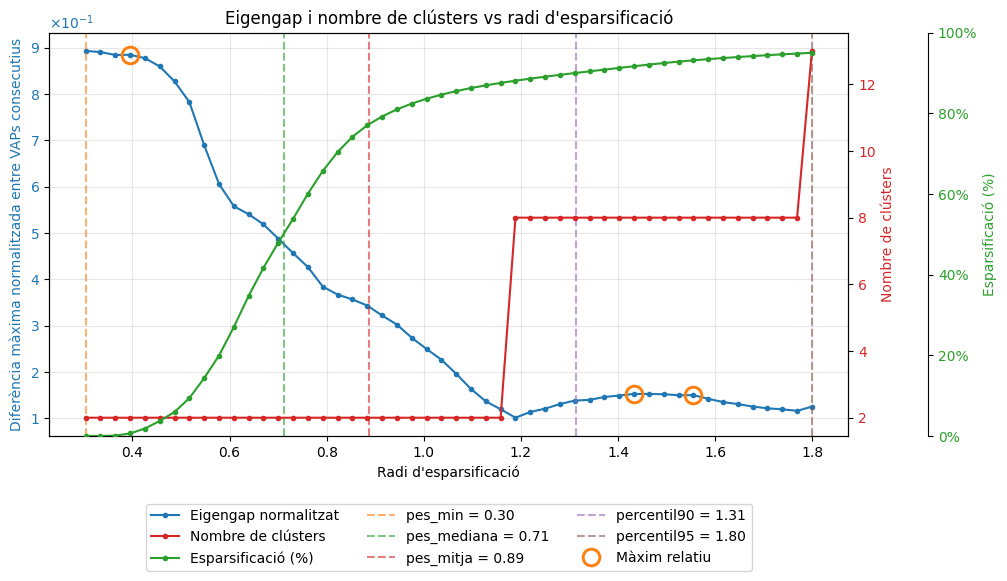

In [10]:
grafica_eigengaps_vs_radi(result, params, indexs_max_rel=indexs_max_rel, 
                          subfolder="autonom_maxs_rels")